<h1 style="text-align:center">Real Estate Price Prediction Project</h1>

### 1. Load Dependencies

In [3]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

%matplotlib inline

### 2. Load Dataset

#### Bengaluru House Price Data

**Dataset URL**: [https://www.kaggle.com/datasets/amitabhajoy/bengaluru-house-price-data](https://www.kaggle.com/datasets/amitabhajoy/bengaluru-house-price-data)


**Dataset Information** 

Attribute Type: Real \
Instances: 13320 \
Attributes: 9 
<br>

**Attributes Information** 
1. area_type	
2. availability	
3. location	
4. size	
5. society	
6. total_sqft	
7. bath	
8. balcony	
9. price  **(Target)**

In [4]:
df = pd.read_csv('./dataset/Bengaluru_House_Data.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


### 3. Data Cleaning

In [5]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [6]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [7]:
df.groupby('area_type')['price'].agg(['count','min','max','mean', 'median'])

,count,min,max,mean,median
area_type,,,,,
Built-up Area,2418,9.00,2050.0,104.285498,70.0
Carpet Area,87,13.00,500.0,89.502356,70.0
Plot Area,2025,8.44,3600.0,208.495486,140.0
Super built-up Area,8790,8.00,2912.0,92.971757,65.0


In [8]:
df.groupby('balcony')['price'].agg(['count','min','max','mean', 'median'])

,count,min,max,mean,median
balcony,,,,,
0.0,1029,10.5,950.0,110.698469,72.02
1.0,4897,8.0,1800.0,85.730063,60.00
2.0,5113,10.0,2912.0,109.981948,75.00
3.0,1672,23.0,2800.0,150.748768,95.00


In [9]:
groupSociety = df.groupby('society')['society'].count()

In [10]:
groupSociety.max()

80

In [11]:
groupSociety[groupSociety == 80]

society
GrrvaGr    80
Name: society, dtype: int64

In [12]:
df[df.society == 'GrrvaGr'].head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
17,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,3 BHK,GrrvaGr,1540,3.0,3.0,60.00
33,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,3 BHK,GrrvaGr,1693,3.0,3.0,57.39
262,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,GrrvaGr,1295,2.0,2.0,43.90
433,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,GrrvaGr,1419,2.0,2.0,48.10
450,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,GrrvaGr,1295,2.0,1.0,55.47
607,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,GrrvaGr,1133,2.0,1.0,49.07
667,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,GrrvaGr,1141,2.0,2.0,38.55
873,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,GrrvaGr,1140,2.0,1.0,49.39
957,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,GrrvaGr,1303,2.0,2.0,55.79
1329,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,GrrvaGr,1143,2.0,2.0,38.65


#### Observations
1. **availability**: This should not have any impact on the price. 
2. **society**: Each society have same area type. So We can drop it by taking **area_type**.
3. **balcony**: The 0 balcony and 3 balcony have no difference in price. So, there is no impact on the price.

So, **area_type**,**availability**,**society**,**balcony** haven't sufficient impact on the price. So, we can drop them.

In [13]:
df2 = df.copy()
df2 = df2.drop(['area_type',	'availability',	'society', 'balcony'], axis=1)
df2.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [14]:
df2.isna().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

#### Observations 
We have 13320 data. So we can drop the NA values. (We also could replace NA by the median of the data)

In [15]:
df3 = df2.copy()
df3 = df3.dropna()
df3.isna().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

### Feature Engineering

In [16]:
df3['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [17]:
df4 = df3.copy()
df4['bhk'] = df4['size'].apply(lambda x: int(x.split(' ')[0]))
df4.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [18]:
df4.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [19]:
def isFloat(x):
    try:
        float(x)
    except:
        return False
    return True

In [20]:
df4[~df4.total_sqft.apply(isFloat)].head(20)    # ~ is the negate operation for print only not float

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


#### Observations
* Some value of **total_sqft** are like a range (Example: 2100 - 2850). So, We can take the middle value of the range.
* Some value of **total_sqft** are in the different units. I am dropping it for the simplicity. 

In [21]:
def convert_sqrt_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1]))/2.0
    try:
        return float(x)
    except:
        return None

In [22]:
df5 = df4.copy()
df5.total_sqft = df5.total_sqft.apply(convert_sqrt_to_num)
df5.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [23]:
df5.loc[30]    # Index 30 was the '2100 - 2850' 

location      Yelahanka
size              4 BHK
total_sqft       2475.0
bath                4.0
price             186.0
bhk                   4
Name: 30, dtype: object

#### Observations
We know that in Reat Estate, **price_per_sqft** is very important. The usually use this matrix for selling the flats. So, I am creating new feature called **price_per_sqft**  

In [24]:
df6 = df5.copy()
df6['price_per_sqft'] = (df6.price * 100000) / df6.total_sqft   # Price is in the lakh 
df6.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


### Dimensionality Reduction

In [25]:
len(df6.location.unique())

1304

In [26]:
df7 = df6.copy()
df7.location = df7.location.apply(lambda x: x.strip())

location_state = df7.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_state

location
Whitefield               535
Sarjapur  Road           392
Electronic City          304
Kanakpura Road           266
Thanisandra              236
                        ... 
1 Giri Nagar               1
Kanakapura Road,           1
Kanakapura main  Road      1
Karnataka Shabarimala      1
whitefiled                 1
Name: location, Length: 1293, dtype: int64

#### Observations
The location which have less thanmpr equal to 10 house should be labeled as 'others' for the simplicity of the data

In [27]:
less_than_ten = location_state[location_state<10]
len(less_than_ten)

1039

In [28]:
df8 = df7.copy()
df8.location = df8.location.apply(lambda x: 'others' if x in less_than_ten else x)
df8.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [29]:
len(df8.location.unique())

255

### Outlier Removal

In [30]:
df8[df8.total_sqft/df8.bhk < 300].head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,others,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.296296
70,others,3 Bedroom,500.0,3.0,100.0,3,20000.000000


In [31]:
df8[df8.total_sqft/df8.bhk < 300].count()

location          744
size              744
total_sqft        744
bath              744
price             744
bhk               744
price_per_sqft    744
dtype: int64

In [32]:
df9 = df8.copy()
df9 = df9[~ (df9.total_sqft/df9.bhk < 300)]
df9.shape

(12502, 7)

In [33]:
df9.price_per_sqft.describe().apply(lambda x: '%.5f' % x)

count     12456.00000
mean       6308.50283
std        4168.12734
min         267.82981
25%        4210.52632
50%        5294.11765
75%        6916.66667
max      176470.58824
Name: price_per_sqft, dtype: object

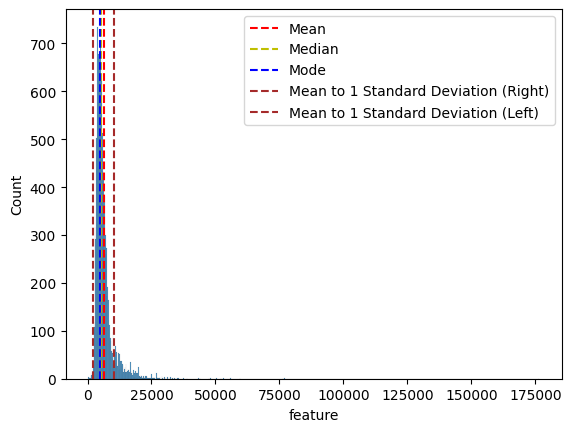

In [34]:
def plot_histogram(df, feature):
    sns.histplot(df[feature], kde=False)

    mean_value = df[feature].mean()
    median_value = df[feature].median()
    mode_value = df[feature].mode().values[0]
    std_value = df[feature].std()

    plt.axvline(mean_value, color='r', linestyle='--', label='Mean')
    plt.axvline(median_value, color='y', linestyle='--', label='Median')
    plt.axvline(mode_value, color='b', linestyle='--', label='Mode')
    plt.axvline(mean_value + std_value, color='brown', linestyle='--', label='Mean to 1 Standard Deviation (Right)')
    plt.axvline(mean_value - std_value, color='brown', linestyle='--', label='Mean to 1 Standard Deviation (Left)')
    plt.xlabel('feature')
    plt.ylabel('Count')

    plt.legend()
    plt.show()

plot_histogram(df9, 'price_per_sqft')

#### Observations
This is the positive skewness. We can remove outliers by taking 1 standard deviation from mean.  

In [35]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out
df10 = df9.copy()
df10 = remove_pps_outliers(df10)
df10.shape

(10222, 7)

In [36]:
df10.groupby('bhk')['price_per_sqft'].describe()

,count,mean,std,min,25%,50%,75%,max
bhk,,,,,,,,
1,517.0,5160.370620,2056.225621,1300.000000,3833.333333,4950.980392,5952.380952,16831.683168
2,4744.0,5097.668423,1694.333483,1937.500000,4000.000000,4844.444444,5786.860782,24166.666667
3,3992.0,5952.874823,2324.476053,2083.333333,4495.788287,5487.907955,6726.135179,22296.774194
4,748.0,7696.608573,3110.751476,1250.000000,5548.792983,7096.774194,8853.077233,24000.000000
5,108.0,7634.183855,4130.791802,1379.310345,4932.151548,6678.250796,9058.256636,24509.803922
6,62.0,7225.458523,4146.977016,3000.000000,4309.523810,5646.464646,9299.569017,19791.666667
7,19.0,5186.730029,3554.236589,1600.000000,3605.456026,4600.000000,5270.833333,18333.333333
8,16.0,5793.408746,3730.406936,2750.000000,4200.000000,4677.083333,5536.684783,18461.538462
9,9.0,6341.412312,4090.288329,3260.869565,4062.500000,4347.826087,6666.666667,15151.515152


#### Observations
Here, the mean price of 6 room is more than 7 room. This is an outlier. 

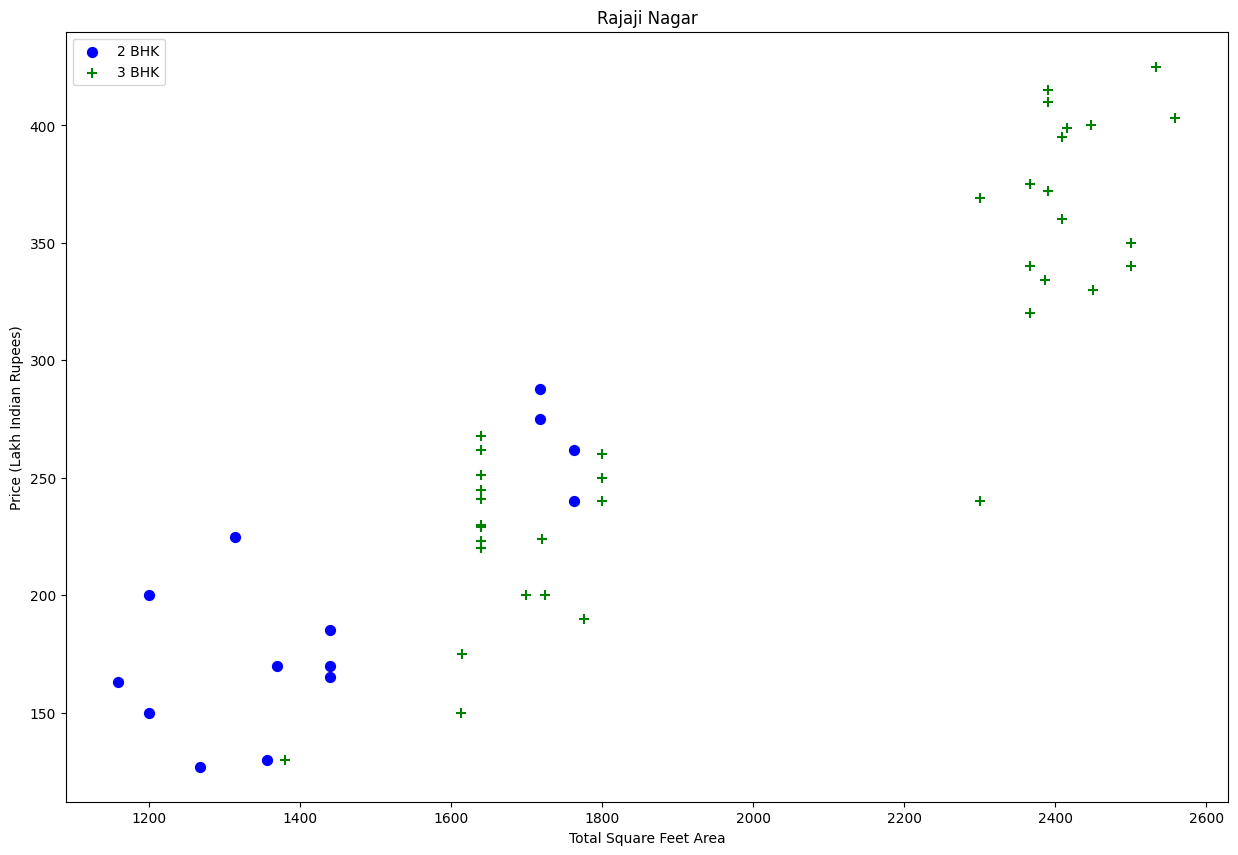

In [37]:
def plot_scatter_chart(df,location):
    bhk2 = df[(df.location==location) & (df.bhk==2)]
    bhk3 = df[(df.location==location) & (df.bhk==3)]
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.total_sqft,bhk2.price,color='blue',label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft,bhk3.price,marker='+', color='green',label='3 BHK', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()
    
plot_scatter_chart(df10,"Rajaji Nagar")

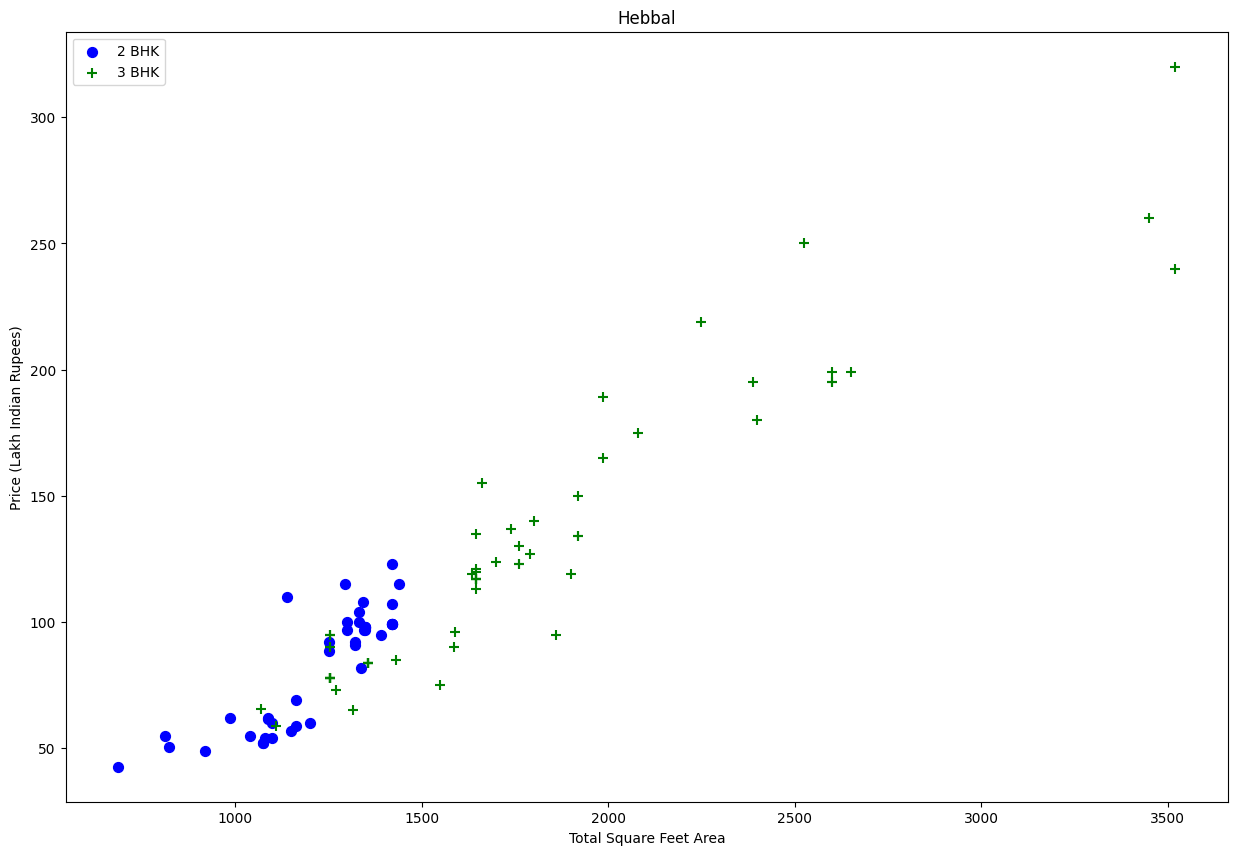

In [38]:
plot_scatter_chart(df10,"Hebbal")

#### Observations
We should also remove properties where for same location, the price of (for example) 3 bedroom apartment is less than 2 bedroom apartment (with same square ft area). What we will do is for a given location, we will build a dictionary of stats per bhk, i.e.

```
{
    '1' : {
        'mean': 4000,
        'std: 2000,
        'count': 34
    },
    '2' : {
        'mean': 4300,
        'std: 2300,
        'count': 22
    },    
}
```

Now we can remove those 2 BHK apartments whose price_per_sqft is less than mean price_per_sqft of 1 BHK apartment



In [39]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices,axis='index')
df11 = df10.copy()
df11 = remove_bhk_outliers(df11)
df11.shape

(7369, 7)

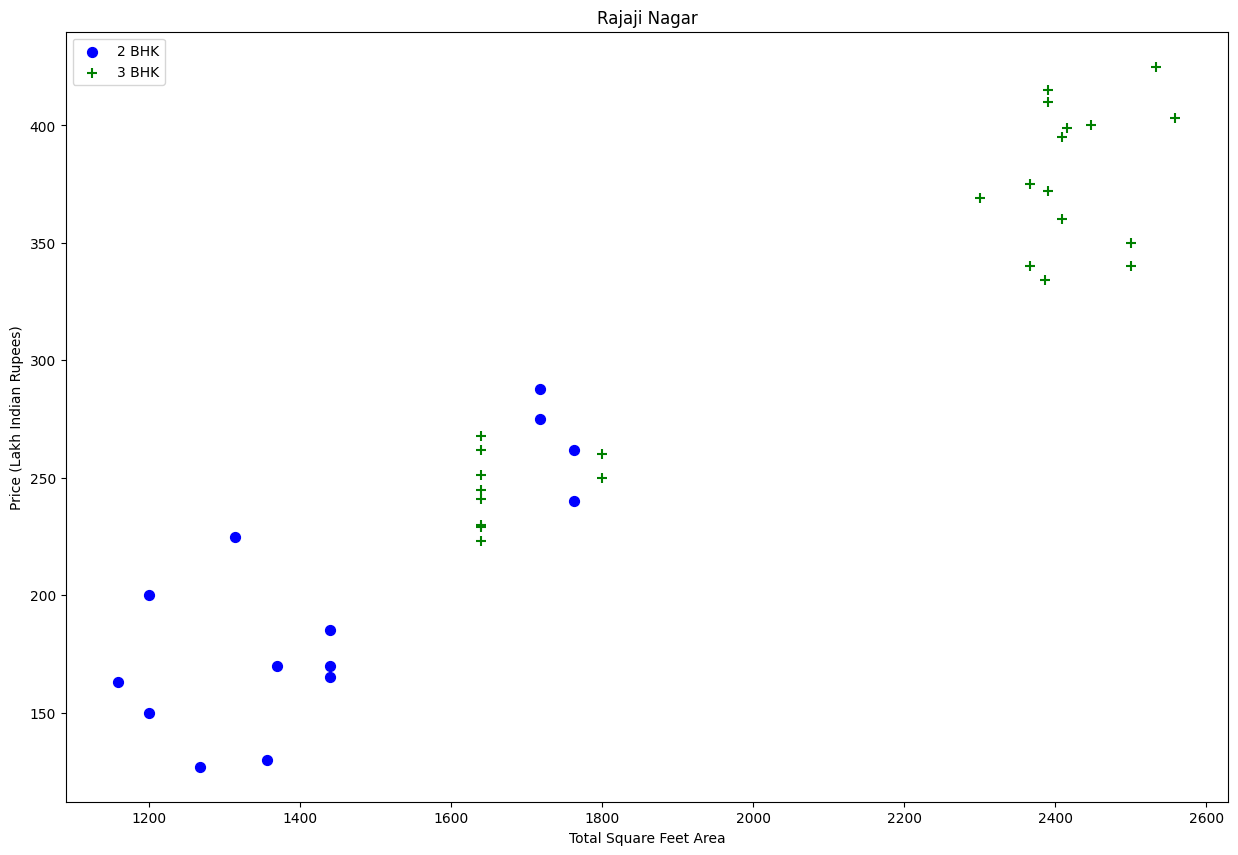

In [40]:
plot_scatter_chart(df11,"Rajaji Nagar")

In [41]:
df11.bath.unique()

array([ 4.,  3.,  2.,  5.,  8.,  1.,  6., 14.,  7.,  9., 12., 16., 13.])

In [42]:
df11[df11.bath>10]


,location,size,total_sqft,bath,price,bhk,price_per_sqft
585,BTM 1st Stage,9 Bedroom,3300.0,14.0,500.0,9,15151.515152
5344,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10,4000.000000
8547,others,10 BHK,12000.0,12.0,525.0,10,4375.000000
8633,others,16 BHK,10000.0,16.0,550.0,16,5500.000000
9329,others,11 BHK,6000.0,12.0,150.0,11,2500.000000
9642,others,13 BHK,5425.0,13.0,275.0,13,5069.124424


Text(0, 0.5, 'Count')

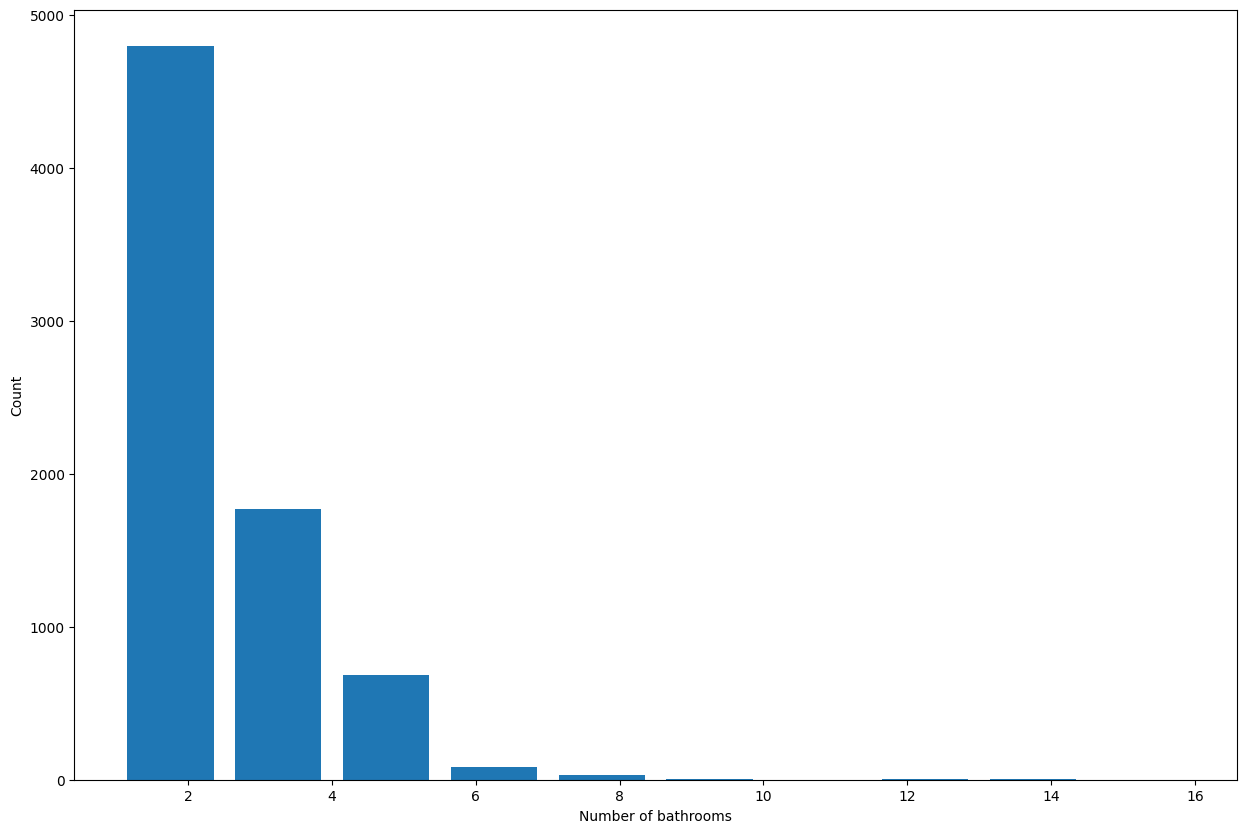

In [43]:
plt.hist(df11.bath,rwidth=0.8)
plt.xlabel("Number of bathrooms")
plt.ylabel("Count")

In [44]:
df11[df11.bath>df11.bhk+2]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
585,BTM 1st Stage,9 Bedroom,3300.0,14.0,500.0,9,15151.515152
1642,Chikkabanavar,4 Bedroom,2460.0,7.0,80.0,4,3252.032520
5305,Nagasandra,4 Bedroom,7000.0,8.0,450.0,4,6428.571429
6792,Thanisandra,3 BHK,1806.0,6.0,116.0,3,6423.034330
8476,others,6 BHK,11338.0,9.0,1000.0,6,8819.897689


#### Observations
Again the business manager has a conversation with you (i.e. a data scientist) that if you have 4 bedroom home and even if you have bathroom in all 4 rooms plus one guest bathroom, you will have total bath = total bed + 1 max. Anything above that is an outlier or a data error and can be removed



In [45]:
df12 = df11.copy()
df12 = df12[(df12.bath)<(df12.bhk+2)]
df12.shape

(7291, 7)

In [46]:
df13 = df12.copy()
df13 = df13.drop(['size','price_per_sqft'],axis='columns')
df13.head(3)

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3


### One Hot Encoding

In [47]:
dummies = pd.get_dummies(df13['location'],dtype=int).drop('others', axis=1)
dummies.head()

,1st Block Jayanagar,1st Block Koramangala,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
df14 = df13.copy()
df14 = pd.concat([df14,dummies], axis=1)
df14.head() 

,location,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Block Koramangala,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.0,4.0,428.0,4,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1st Block Jayanagar,1630.0,3.0,194.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1st Block Jayanagar,1875.0,2.0,235.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1st Block Jayanagar,1200.0,2.0,130.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1st Block Jayanagar,1235.0,2.0,148.0,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
df15 = df14.copy()
df15 = df15.drop('location', axis=1)
df15.head()

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Block Koramangala,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,428.0,4,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,194.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875.0,2.0,235.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1200.0,2.0,130.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1235.0,2.0,148.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Training

In [50]:
df15.shape

(7291, 258)

In [51]:
Y = df15.price
X = df15.drop('price', axis=1)

x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=.2, random_state=5)

In [52]:
model = LinearRegression()
model.fit(x_train.values, y_train)

LinearRegression()

In [53]:
model.score(x_test.values, y_test)

0.8987778803544371

### Cross Validation

In [54]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=10, test_size=.2, random_state=5)
cross_val_score(LinearRegression(),X,Y,cv=cv)

array([0.89877788, 0.85492691, 0.84870379, 0.84854163, 0.85944703,
       0.86426367, 0.84237607, 0.85295726, 0.88787444, 0.83190743])

### Find best model using GridSearchCV


In [110]:
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor

def find_best_model_using_gridsearchcv(X,y):
    algos = {
        'linear_regression' : {
            'model': LinearRegression(),
            'params': {}
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1,2],
                'selection': ['random', 'cyclic'],
            }
        },
        'ridge':{
            'model': Ridge(),
            'params': {
                'alpha': [1,2],
                'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            }
        },
        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion' : ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
                'splitter': ['best','random']
            }
        }
    }
    scores = []
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
    for algo_name, config in algos.items():
        gs =  GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
        gs.fit(X,Y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(scores,columns=['model','best_score','best_params'])

find_best_model_using_gridsearchcv(X,Y)

So, we have got our best model **LinearRegression**

### Test the model for few properties


In [55]:
def predict_price(location,sqft,bath,bhk):    
    loc_index = np.where(X.columns==location)[0][0]

    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk
    if loc_index >= 0:
        x[loc_index] = 1

    return model.predict([x])[0]

In [56]:
predict_price('1st Phase JP Nagar',1000, 2, 2)

86.07877052398779

In [57]:
predict_price('1st Phase JP Nagar',1000, 3, 3)

88.7315819483936

### Export the tested model to a pickle file


In [58]:
import pickle
with open('banglore_home_prices_model.pickle','wb') as f:
    pickle.dump(model,f)

### Export location and column information to a file that will be useful later on in our prediction application


In [59]:
import json
columns = {
    'data_columns' : [col.lower() for col in X.columns]
}
with open("columns.json","w") as f:
    f.write(json.dumps(columns))